# Combined Analysis Pipeline for EEG Poem Study

This notebook combines ordinal classifier models (statsmodels) and LightGBM models for analyzing EEG data across different poetic conditions and aesthetic judgment targets.

In [16]:
import numpy as np
import pandas as pd
import os
import warnings
import re
from scipy.stats import norm, chi2
import joblib

# Preprocessing
from sklearn.preprocessing import PowerTransformer, LabelBinarizer

# Models
import xgboost as xgb
import lightgbm as lgb
from xgboost import plot_importance
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, cohen_kappa_score, make_scorer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.figsize': (20, 16)})

## Data Loading and Preparation

In [2]:
# Import the features
df_feat = pd.read_csv('../project_eeg/data/features/mean_power_by_epochs_granular.csv')
df_feat.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(0, 5)_alpha","CL6_(0, 5)_beta","CL6_(0, 5)_delta","CL6_(0, 5)_lower gamma","CL6_(0, 5)_theta","CL6_(5, 10)_alpha","CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta"
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,1.537287e-09,3.561905e-10,4.908325e-09,6.962249e-11,1.729118e-09,1.202900e-09,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,1.211884e-09,3.354284e-10,5.194283e-09,6.609093e-11,1.488689e-09,9.004423e-10,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,1.663328e-09,4.766676e-10,4.582519e-09,6.637577e-11,1.316288e-09,1.119152e-09,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,1.236335e-09,4.668531e-10,3.786341e-09,7.868001e-11,1.832124e-09,1.673658e-09,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,1.190958e-09,4.125246e-10,5.845627e-09,8.286195e-11,1.713941e-09,9.169432e-10,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09


In [3]:
df_target = pd.read_csv('../project_eeg/data/target.csv')
df_target.head()

,Unnamed: 0,Participant,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,0,1,H,6,6,6,5,6
1,1,1,H,6,6,6,5,5
2,2,1,H,6,6,6,5,6
3,3,1,H,6,6,5,6,6
4,4,1,H,6,6,5,4,5


In [4]:
df_target['subject_name'] = ['P10'+str(x) if len(str(x))<=1 else 'P1'+str(x) for x in df_target.Participant]
df_target = df_target.drop(columns=['Unnamed: 0', 'Participant'])
df_target.head()

,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,subject_name
0,H,6,6,6,5,6,P101
1,H,6,6,6,5,5,P101
2,H,6,6,6,5,6,P101
3,H,6,6,5,6,6,P101
4,H,6,6,5,4,5,P101


In [5]:
df_target['epoch'] = df_target.groupby(by='subject_name').cumcount()+1
df_target.head()

,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,subject_name,epoch
0,H,6,6,6,5,6,P101,1
1,H,6,6,6,5,5,P101,2
2,H,6,6,6,5,6,P101,3
3,H,6,6,5,6,6,P101,4
4,H,6,6,5,4,5,P101,5


In [6]:
df = pd.merge(df_feat, df_target, how='left', on=['subject_name','epoch'])
df.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta",PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09,H,6,6,6,5,6
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09,H,6,6,6,5,5
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09,H,6,6,6,5,6
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09,H,6,6,5,6,6
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09,H,6,6,5,4,5


In [7]:
# Exclude 4 subjects with less data
list_to_drop = ['P105', 'P141', 'P142', 'P146']
df_filtered = df[~df.subject_name.isin(list_to_drop)]

In [8]:
## Divide data into different stimuli
df_haiku = df_filtered[df_filtered.PoemType=='H']
df_senryu = df_filtered[df_filtered.PoemType=='S']
df_control = df_filtered[df_filtered.PoemType=='C']

# Store all datasets in a dictionary
datasets = {
    'haiku': df_haiku,
    'senryu': df_senryu,
    'control': df_control
}

In [9]:
# Define target variables
cols_target = ['Aesthetic_Appeal', 'Vivid_Imagery', 'Moved', 'Originality', 'Creativity']

# Process each dataset - remove PoemType column
for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    # Drop the poem type column
    df_copy = df_copy.drop(columns='PoemType')
    
    # Add df_copy to the dictionary of binary datasets
    datasets[stimulus] = df_copy

In [10]:
# Make X, y, train-test split for each stimulus and target
split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:, 2:-5]
    y = df_copy.iloc[:, -5:]
    
    for col_target in cols_target:
        # Train-test split with stratification
        X_train, X_test, y_train, y_test = train_test_split(
            X, y[col_target], test_size=0.2, random_state=42, stratify=y[col_target]
        )
        
        stimulus_target = f"{stimulus}_{col_target}"
    
        split_datasets[stimulus_target] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X': X,
            'y': y[col_target]
        }

In [11]:
# Create normalized versions of the datasets for the linear models
normalised_split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:, 2:-5]
    y = df_copy.iloc[:, -5:]
    
    # Normalize the variables using Yeo-Johnson transformation
    transformer = PowerTransformer(method='yeo-johnson')
    X_transformed = transformer.fit_transform(X)
    X_transformed = pd.DataFrame(X_transformed, columns=X.columns)
    
    # Create train-test splits for each target
    for col_target in cols_target:
        X_train, X_test, y_train, y_test = train_test_split(
            X_transformed, y[col_target], test_size=0.2, random_state=42, stratify=y[col_target]
        )
    
        stimulus_target = f"{stimulus}_{col_target}"
        
        normalised_split_datasets[stimulus_target] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X_transformed': X_transformed,
            'y': y[col_target]
        }

## Statsmodels OrderedModel Implementation

In [12]:
# Dictionary to store statsmodels results
linear_results_sm = {}

# Loop through all stimulus-target combinations
for stimulus_target, df in normalised_split_datasets.items():
    
    print(f"Running statsmodels ordinal regression for {stimulus_target}")
    
    # Grid search parameters
    hyperparameters = {
        'distr': ['logit', 'probit'],  # Different link functions
        'method': ['lbfgs', 'cg', 'powell'],  # Optimization methods
    }

    # Create a KFold object for cross-validation (CV=3)
    kf = KFold(n_splits=3)

    # Initialize best score tracking variables
    best_score = -np.inf
    best_kappa = -np.inf
    best_params = None
    best_model = None

    # Ignore warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Manual grid search over hyperparameters
        for distr in hyperparameters['distr']:
            for method in hyperparameters['method']:
                # Initialize the cross-validation score
                cv_scores = []
                cv_kappas = []
    
                # Perform cross-validation
                for train_index, val_index in kf.split(df['X_train']):
                    # Split the data
                    X_train_cv, X_val_cv = df['X_train'].iloc[train_index], df['X_train'].iloc[val_index]
                    y_train_cv, y_val_cv = df['y_train'].iloc[train_index], df['y_train'].iloc[val_index]
        
                    # Reset the indices
                    X_train_cv.reset_index(drop=True, inplace=True)
                    X_val_cv.reset_index(drop=True, inplace=True)
                    y_train_cv.reset_index(drop=True, inplace=True)
                    y_val_cv.reset_index(drop=True, inplace=True)
        
                    # Train the ordinal model
                    model = OrderedModel(y_train_cv, X_train_cv, distr=distr)
                    ordinal_model_fit = model.fit(method=method, disp=False)
        
                    # Predict the validation set results
                    y_prob = ordinal_model_fit.predict(X_val_cv)
                
                    # Convert cumulative probabilities to class probabilities
                    y_prob_class = np.column_stack([y_prob.iloc[:, 0], np.diff(y_prob, axis=1)])

                    # Calculate ROC AUC score
                    y_val_binarized = LabelBinarizer().fit_transform(y_val_cv)
                    roc_auc = roc_auc_score(y_val_binarized, y_prob_class, average="macro", multi_class="ovr")
                    cv_scores.append(roc_auc)
                
                    # Predict class labels for validation set
                    predicted_probabilities = ordinal_model_fit.model.predict(ordinal_model_fit.params, exog=X_val_cv)
                    predicted_classes = np.argmax(predicted_probabilities, axis=1) + 1  # +1 to adjust for 1-based classes

                    # Compute Cohen's Kappa
                    kappa_score_sm = cohen_kappa_score(y_val_cv, predicted_classes)
                    cv_kappas.append(kappa_score_sm)

                # Calculate average scores across CV folds
                avg_roc_auc = np.mean(cv_scores)
                avg_kappa = np.mean(cv_kappas)
                
                print(f"Params: distr={distr}, method={method}, Avg ROC AUC: {avg_roc_auc:.4f}, Avg Kappa: {avg_kappa:.4f}")
                
                # Update the best model if the score is higher
                if avg_roc_auc > best_score:
                    best_score = avg_roc_auc
                    best_kappa = avg_kappa
                    best_params = {'distr': distr, 'method': method}
        
        print(f"Best Parameters: {best_params}, Best ROC AUC: {best_score:.4f}, Best Kappa: {best_kappa:.4f}")
        
        # Retrain on all data with best parameters
        y_sm = df['y'].reset_index(drop=True)
        sm_best = OrderedModel(y_sm, df['X_transformed'], distr=best_params['distr'])
        best_result = sm_best.fit(method=best_params['method'], disp=False)
        
        # Evaluate on test set
        X_test_sm = df['X_test'].reset_index(drop=True)
        y_test_sm = df['y_test'].reset_index(drop=True)
        
        # Predict probabilities and classes
        test_probabilities = best_result.predict(X_test_sm)
        test_prob_class = np.column_stack([test_probabilities.iloc[:, 0], np.diff(test_probabilities, axis=1)])
        test_predicted_classes = np.argmax(test_probabilities.values, axis=1) + 1
        
        # Calculate metrics
        test_roc_auc = roc_auc_score(
            LabelBinarizer().fit_transform(y_test_sm), 
            test_prob_class, 
            average="macro", 
            multi_class="ovr"
        )
        test_kappa = cohen_kappa_score(y_test_sm, test_predicted_classes)
        
        print(f"Test ROC AUC: {test_roc_auc:.4f}, Test Kappa: {test_kappa:.4f}")
        
        # Save the model (storing the result and parameters)
        model_info = {
            'result': best_result,
            'distr': best_params['distr'],
            'method': best_params['method']
        }
        model_filename = os.path.join('models', f'statsmodels_ordinal_{stimulus_target}.joblib')
        joblib.dump(model_info, model_filename)
        print(f"Model saved to {model_filename}")
        
        # Store results in dictionary
        linear_results_sm[stimulus_target] = {
            'best_params': best_params,
            'cv_roc_auc': best_score,
            'cv_kappa_score': best_kappa,
            'test_roc_auc': test_roc_auc,
            'test_kappa_score': test_kappa,
            'features': list(df['X_transformed'].columns),
            'params': list(best_result.params)[:-6],  # Exclude the cutpoints/thresholds
            'p_values': list(best_result.pvalues)[:-6],  # Exclude the cutpoints/thresholds
            'model_file': model_filename
        }
        print("-----------------------\n")

Running statsmodels ordinal regression for haiku_Aesthetic_Appeal
Params: distr=logit, method=lbfgs, Avg ROC AUC: 0.5532, Avg Kappa: 0.0385
Params: distr=logit, method=cg, Avg ROC AUC: 0.5532, Avg Kappa: 0.0385
Params: distr=logit, method=powell, Avg ROC AUC: 0.5569, Avg Kappa: 0.0313
Params: distr=probit, method=lbfgs, Avg ROC AUC: 0.5515, Avg Kappa: 0.0273
Params: distr=probit, method=cg, Avg ROC AUC: 0.5515, Avg Kappa: 0.0272
Params: distr=probit, method=powell, Avg ROC AUC: 0.5553, Avg Kappa: 0.0223
Best Parameters: {'distr': 'logit', 'method': 'powell'}, Best ROC AUC: 0.5569, Best Kappa: 0.0313
Test ROC AUC: 0.5622, Test Kappa: 0.0406
Model saved to models/statsmodels_ordinal_haiku_Aesthetic_Appeal.joblib
-----------------------

Running statsmodels ordinal regression for haiku_Vivid_Imagery
Params: distr=logit, method=lbfgs, Avg ROC AUC: 0.5589, Avg Kappa: 0.0468
Params: distr=logit, method=cg, Avg ROC AUC: 0.5588, Avg Kappa: 0.0474
Params: distr=logit, method=powell, Avg ROC AUC

Params: distr=logit, method=cg, Avg ROC AUC: 0.5117, Avg Kappa: 0.0657
Params: distr=logit, method=powell, Avg ROC AUC: 0.5120, Avg Kappa: 0.0662
Params: distr=probit, method=lbfgs, Avg ROC AUC: 0.5278, Avg Kappa: 0.0702
Params: distr=probit, method=cg, Avg ROC AUC: 0.5278, Avg Kappa: 0.0702
Params: distr=probit, method=powell, Avg ROC AUC: 0.5273, Avg Kappa: 0.0666
Best Parameters: {'distr': 'probit', 'method': 'lbfgs'}, Best ROC AUC: 0.5278, Best Kappa: 0.0702
Test ROC AUC: 0.5326, Test Kappa: 0.0650
Model saved to models/statsmodels_ordinal_control_Vivid_Imagery.joblib
-----------------------

Running statsmodels ordinal regression for control_Moved
Params: distr=logit, method=lbfgs, Avg ROC AUC: 0.5261, Avg Kappa: 0.1039
Params: distr=logit, method=cg, Avg ROC AUC: 0.5261, Avg Kappa: 0.1048
Params: distr=logit, method=powell, Avg ROC AUC: 0.5250, Avg Kappa: 0.1022
Params: distr=probit, method=lbfgs, Avg ROC AUC: 0.5425, Avg Kappa: 0.0955
Params: distr=probit, method=cg, Avg ROC AUC

## LightGBM Ordinal Model

In [17]:
# Initialize dictionaries to store results
lgb_results_matrix = {key: {} for key in split_datasets.keys()}
lightgbm_results = {}

# LightGBM model training and evaluation loop
for stimulus_target, df in split_datasets.items():
    print(f"Running LightGBM model for {stimulus_target}")
    
    # Clean column names for consistency
    df['X'].columns = [re.sub(r'[^\w\s]', '', col) for col in df['X'].columns]
    df['X_test'].columns = [re.sub(r'[^\w\s]', '', col) for col in df['X_test'].columns]
    
    # Define the parameter grid for random search
    param_distributions = {
        "boosting_type": ["gbdt", "dart"],
        "num_leaves": np.arange(20, 101, 10),
        "learning_rate": np.logspace(-4, -1, 10),
        "n_estimators": np.arange(100, 801, 100),
        "min_data_in_leaf": np.arange(10, 101, 10),
        "lambda_l1": np.linspace(0.0, 10.0, 10),
        "lambda_l2": np.linspace(0.0, 10.0, 10),
        "feature_fraction": np.linspace(0.5, 1.0, 6),
        "bagging_fraction": np.linspace(0.5, 1.0, 6),
        "bagging_freq": np.arange(1, 8),
        "max_depth": np.arange(3, 12),
    }

    # Initialize LightGBM classifier
    lgbm_model = lgb.LGBMClassifier(objective="multiclass", num_class=7, random_state=42)

    # Perform randomized search with CV=3
    random_search = RandomizedSearchCV(
        estimator=lgbm_model,
        param_distributions=param_distributions,
        n_iter=30,  # Number of parameter settings sampled
        scoring="roc_auc_ovr",
        cv=3,  # Using CV=3
        verbose=0,
        random_state=42,
        n_jobs=-1  # Use all available cores
    )

    # Fit the randomized search
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        random_search.fit(df["X"], df["y"])

    # Get best parameters
    lgb_best_params = random_search.best_params_
    print("Best Parameters:", lgb_best_params)

    # Evaluate on test set
    y_pred = random_search.predict(df["X_test"])
    y_pred_proba = random_search.predict_proba(df["X_test"])

    # Print classification report
    print(classification_report(df["y_test"], y_pred))
    print("Confusion Matrix:\n", confusion_matrix(df["y_test"], y_pred))

    # Compute ROC AUC score and Cohen's Kappa
    lgb_roc_auc = roc_auc_score(
        LabelBinarizer().fit_transform(df["y_test"]), 
        y_pred_proba, 
        average="macro", 
        multi_class="ovr"
    )
    lgb_kappa = cohen_kappa_score(df["y_test"], y_pred, weights="quadratic")
    print(f"ROC AUC: {lgb_roc_auc:.4f}")
    print(f"Cohen's Kappa: {lgb_kappa:.4f}")

    # Calculate confidence intervals using 5-fold CV
    lgbm_optimal = lgb.LGBMClassifier(**lgb_best_params, objective="multiclass", num_class=7, verbose=-1)
    cv_scores = cross_val_score(lgbm_optimal, df["X"], df["y"], cv=5, scoring='roc_auc_ovr')
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    cv_ci_lower = cv_mean - 1.96 * cv_std / np.sqrt(5)  # 95% confidence interval
    cv_ci_upper = cv_mean + 1.96 * cv_std / np.sqrt(5)
    
    print(f"5-Fold CV ROC AUC: {cv_mean:.4f} (95% CI: [{cv_ci_lower:.4f}, {cv_ci_upper:.4f}])")

    # Retrain the best model on all data
    lgbm_model_final = lgb.LGBMClassifier(**lgb_best_params, objective="multiclass", num_class=7, verbose=-1)
    lgbm_model_final.fit(
        df["X"],
        df["y"],
        eval_set=[(df["X_test"], df["y_test"])],  # Use test set for early stopping
        eval_metric="multi_logloss",
        early_stopping_rounds=20,
        verbose=0
    )

    # Save final model
    model_filename = os.path.join('models', f'lightgbm_model_{stimulus_target}.joblib')
    joblib.dump(lgbm_model_final, model_filename)
    print(f"Model saved to {model_filename}")
    
    # Store the results
    lightgbm_results[stimulus_target] = {
        'best_params': lgb_best_params,
        'roc_auc': lgb_roc_auc,
        'kappa_score': lgb_kappa,
        'cv_roc_auc': cv_mean,
        'cv_roc_auc_ci': [cv_ci_lower, cv_ci_upper],
        'features': df['X'].columns,
        'feature_importances': lgbm_model_final.feature_importances_,
        'model_file': model_filename
    }
    
    # Initialize performance storage for this model
    if 'performance' not in lgb_results_matrix[stimulus_target]:
        lgb_results_matrix[stimulus_target]['performance'] = {}
    
    # Evaluate this model on all other datasets
    for test_stimulus_target, test_df in split_datasets.items():
        print(f"Evaluating {stimulus_target} model on {test_stimulus_target}")
        
        # Clean column names
        test_df['X_test'].columns = [re.sub(r'[^\w\s]', '', col) for col in test_df['X_test'].columns]
            
        # Make predictions
        y_pred_test = lgbm_model_final.predict(test_df['X_test'])
        y_prob_test = lgbm_model_final.predict_proba(test_df['X_test'])

        # Compute metrics on test set
        cm_lgb = confusion_matrix(test_df['y_test'], y_pred_test)
        roc_auc_lgb = roc_auc_score(
            LabelBinarizer().fit_transform(test_df['y_test']), 
            y_prob_test, 
            average="macro", 
            multi_class="ovr"
        )
        kappa_score_lgb = cohen_kappa_score(test_df['y_test'], y_pred_test, weights='quadratic')

        # Perform 5-fold CV evaluation for cross-dataset performance
        # We need to combine X and X_test, y and y_test for the cross-validation
        if 'X_train' in test_df and 'y_train' in test_df:
            X_combined = pd.concat([test_df['X_train'], test_df['X_test']], axis=0)
            y_combined = pd.concat([test_df['y_train'], test_df['y_test']], axis=0)
        else:
            # If train set is not available in the test_df, use what's available
            X_combined = test_df['X_test']
            y_combined = test_df['y_test']
        
        # Clean combined column names
        X_combined.columns = [re.sub(r'[^\w\s]', '', col) for col in X_combined.columns]

        # Save results in the matrix
        lgb_results_matrix[stimulus_target]['performance'][test_stimulus_target] = {
            'roc_auc': roc_auc_lgb,
            'kappa_score': kappa_score_lgb,
            'confusion_matrix': cm_lgb,
            'cv_roc_auc': cv_cross_mean,
            'cv_roc_auc_ci': [cv_cross_ci_lower, cv_cross_ci_upper] if cv_cross_mean is not None else None
        }
            
        print(f"ROC AUC ({stimulus_target} on {test_stimulus_target}): {roc_auc_lgb:.4f}")
        print(f"Cohen's Kappa ({stimulus_target} on {test_stimulus_target}): {kappa_score_lgb:.4f}")
        print("-----------------------")
    
    print("\n")

Running LightGBM model for haiku_Aesthetic_Appeal
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Best Parameters: {'num_leaves': 60, 'n_estimators': 700, 'min_data_in_leaf': 100, 'max_depth': 4, 'learning_rate': 0.00021544346900318845, 'lambda_l2': 1.1111111111111112, 'lambda_l1': 4.444444444444445, 'feature

/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2

/opt/homebrew/lib/python3.9/site-packages/lightgbm/sklearn.py:726: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/opt/homebrew/lib/python3.9/site-packages/lightgbm/sklearn.py:736: UserWarning: 'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose' argument is deprecated and will be removed in a future release of LightGBM. "
/opt/homebrew/lib/python3.9/site-packages/lightgbm/callback.py:223: UserWarning: Early stopping is not available in dart mode
  _log_warning('Early stopping is not available in dart mode')


Model saved to models/lightgbm_model_haiku_Aesthetic_Appeal.joblib
Evaluating haiku_Aesthetic_Appeal model on haiku_Aesthetic_Appeal
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Error in CV fold: Feature (CL1_4_0_alpha) appears more than one time.
Could not complete CV for haiku_Aesthetic_Appeal on haiku_A

...

[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.


[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Error in CV fold: Feature (CL1_4_0_alpha) appears more than one time.
Could not complete CV for control_Creativity on senryu_Aesthetic_Appeal
ROC AUC (control_Creativity on senryu_Aesthetic_Appeal): 0.5318
Cohen's Kappa (control_Creativity on senryu_Aesthetic_Appe

[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.


Error in CV fold: Feature (CL1_4_0_alpha) appears more than one time.
Could not complete CV for control_Creativity on control_Aesthetic_Appeal
ROC AUC (control_Creativity on control_Aesthetic_Appeal): 0.6545
Cohen's Kappa (control_Creativity on control_Aesthetic_Appeal): 0.0000
-----------------------
Evaluating control_Creativity model on control_Vivid_Imagery
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 

[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.
[LightGBM] [Fatal] Feature (CL1_4_0_alpha) appears more than one time.


In [47]:
def perform_cv_evaluation(lgb_results_matrix, split_datasets):
    """
    Performs cross-validation evaluation for all saved models across all datasets.
    """
    
    print("Starting cross-validation evaluation for saved models...")
    
    # Function to standardize column names consistently
    def standardize_columns(columns):
        # First replace any whitespace with underscore
        cols = [re.sub(r'\s+', '_', col) for col in columns]
        # Then remove any non-alphanumeric characters except underscores
        cols = [re.sub(r'[^\w]', '', col) for col in cols]
        return cols
    
    # Function to make column names unique
    def make_unique_columns(df):
        seen = {}
        new_cols = []
        for col in df.columns:
            if col in seen:
                seen[col] += 1
                new_col = f"{col}_{seen[col]}"
                new_cols.append(new_col)
            else:
                seen[col] = 0
                new_cols.append(col)
        df.columns = new_cols
        return df
    
    # Iterate through all model source datasets
    for stimulus_target in lgb_results_matrix.keys():
        # Get the path to the saved model
        model_filename = f'models/lightgbm_model_{stimulus_target}.joblib'
        print(f"\nEvaluating model trained on {stimulus_target}")
        
        try:
            # Load the saved model
            lgbm_model_final = joblib.load(model_filename)
            print(f"Successfully loaded model from {model_filename}")
            
            # Get the expected feature names from the model
            model_features = lgbm_model_final.feature_name_
            print(f"Model has {len(model_features)} features")
            print(f"First few features: {model_features[:5]}")
            
            # Check for duplicates in model features
            if len(model_features) != len(set(model_features)):
                print("WARNING: Model has duplicate feature names!")
                # Count duplicates
                from collections import Counter
                feature_counts = Counter(model_features)
                duplicates = [f for f, count in feature_counts.items() if count > 1]
                print(f"Duplicate features in model: {duplicates}")
            
            # Evaluate this model on all datasets
            for test_stimulus_target, test_df in split_datasets.items():
                print(f"\n--- Performing CV for {stimulus_target} model on {test_stimulus_target} data ---")
                
                # Combine data for cross-validation
                if 'X_train' in test_df and 'y_train' in test_df:
                    X_combined = pd.concat([test_df['X_train'], test_df['X_test']], axis=0)
                    y_combined = pd.concat([test_df['y_train'], test_df['y_test']], axis=0)
                else:
                    # If train set is not available, use what's available
                    X_combined = test_df['X_test']
                    y_combined = test_df['y_test']
                
                # Create a copy of the data with appropriately processed column names
                X_processed = X_combined.copy()
                
                # Make sure there are no duplicates in the data columns
                X_processed = make_unique_columns(X_processed)
                
                # Now try to match features using a best-effort approach
                common_features = []
                missing_features = []
                
                for model_feat in model_features:
                    # Check if this exact feature exists in our data
                    if model_feat in X_processed.columns:
                        common_features.append(model_feat)
                    else:
                        # Try a case-insensitive match
                        matches = [col for col in X_processed.columns 
                                  if col.lower() == model_feat.lower()]
                        if matches:
                            # Use the first match
                            X_processed.rename(columns={matches[0]: model_feat}, inplace=True)
                            common_features.append(model_feat)
                        else:
                            # Try standardizing both and comparing
                            model_feat_std = standardize_columns([model_feat])[0]
                            for col in X_processed.columns:
                                col_std = standardize_columns([col])[0]
                                if col_std == model_feat_std:
                                    X_processed.rename(columns={col: model_feat}, inplace=True)
                                    common_features.append(model_feat)
                                    break
                            else:
                                missing_features.append(model_feat)
                
                # Report feature matching results
                print(f"Successfully matched {len(common_features)} out of {len(model_features)} features")
                if missing_features:
                    print(f"Missing {len(missing_features)} features: {missing_features[:5]}{'...' if len(missing_features) > 5 else ''}")
                    
                    # If too many features are missing, skip this dataset
                    if len(missing_features) > len(model_features) * 0.1:  # More than 10% missing
                        print(f"Too many features missing, skipping CV for {stimulus_target} on {test_stimulus_target}")
                        cv_cross_mean = None
                        cv_cross_ci_lower = None
                        cv_cross_ci_upper = None
                        continue
                
                # Select only the needed features in the right order
                X_selected = X_processed[common_features]
                
                # Perform 5-fold CV
                cv_scores_cross = []
                
                try:
                    # Define the 5-fold split
                    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
                    
                    # Track fold success/failure
                    fold_results = {i: "Not attempted" for i in range(5)}
                    
                    # Perform the cross-validation
                    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_selected, y_combined)):
                        X_cv_train, X_cv_val = X_selected.iloc[train_idx], X_selected.iloc[val_idx]
                        y_cv_train, y_cv_val = y_combined.iloc[train_idx], y_combined.iloc[val_idx]
                        
                        # Try fitting the model with specific error handling
                        try:
                            # Check class balance
                            if len(np.unique(y_cv_train)) < lgbm_model_final.n_classes_:
                                print(f"Fold {fold_idx}: Insufficient class representation in training set")
                                fold_results[fold_idx] = "Class imbalance"
                                continue
                            
                            # Make a copy of the model for this fold
                            model_copy = joblib.load(model_filename)
                            
                            # Column check for debugging
                            if len(X_cv_train.columns) != len(set(X_cv_train.columns)):
                                print(f"Fold {fold_idx}: WARNING - Duplicate columns in training data")
                                dup_cols = [col for col, count in Counter(X_cv_train.columns).items() if count > 1]
                                print(f"Duplicates: {dup_cols}")
                                fold_results[fold_idx] = "Duplicate columns"
                                continue
                            
                            # Fit and evaluate
                            model_copy.fit(X_cv_train, y_cv_train)
                            y_cv_prob = model_copy.predict_proba(X_cv_val)
                            
                            # Check validation set class balance
                            if len(np.unique(y_cv_val)) < 2:
                                print(f"Fold {fold_idx}: Validation set has fewer than 2 classes")
                                fold_results[fold_idx] = "Insufficient classes in validation"
                                continue
                            
                            # Calculate ROC AUC
                            fold_score = roc_auc_score(
                                LabelBinarizer().fit_transform(y_cv_val),
                                y_cv_prob,
                                average="macro",
                                multi_class="ovr"
                            )
                            cv_scores_cross.append(fold_score)
                            fold_results[fold_idx] = "Success"
                            print(f"Fold {fold_idx} ROC AUC: {fold_score:.4f}")
                            
                        except ValueError as ve:
                            print(f"Fold {fold_idx}: Value error: {ve}")
                            fold_results[fold_idx] = f"ValueError: {ve}"
                            continue
                            
                        except KeyError as ke:
                            print(f"Fold {fold_idx}: Key error (possibly feature mismatch): {ke}")
                            fold_results[fold_idx] = f"KeyError: {ke}"
                            continue
                            
                        except Exception as e:
                            print(f"Fold {fold_idx}: Unexpected error: {e}")
                            fold_results[fold_idx] = f"Exception: {e}"
                            continue
                    
                    # Print fold status summary and calculate statistics
                    print(f"CV fold results for {stimulus_target} on {test_stimulus_target}:")
                    for fold_idx, status in fold_results.items():
                        print(f"  Fold {fold_idx}: {status}")
                    
                    # Calculate statistics based on number of successful folds
                    if len(cv_scores_cross) >= 3:
                        cv_cross_mean = np.mean(cv_scores_cross)
                        cv_cross_std = np.std(cv_scores_cross)
                        cv_cross_ci_lower = cv_cross_mean - 1.96 * cv_cross_std / np.sqrt(len(cv_scores_cross))
                        cv_cross_ci_upper = cv_cross_mean + 1.96 * cv_cross_std / np.sqrt(len(cv_scores_cross))
                    elif len(cv_scores_cross) > 0:
                        cv_cross_mean = np.mean(cv_scores_cross)
                        cv_cross_std = np.std(cv_scores_cross) if len(cv_scores_cross) > 1 else 0
                        cv_cross_ci_lower = cv_cross_mean - 2.576 * cv_cross_std / np.sqrt(len(cv_scores_cross))
                        cv_cross_ci_upper = cv_cross_mean + 2.576 * cv_cross_std / np.sqrt(len(cv_scores_cross))
                    else:
                        cv_cross_mean = None
                        cv_cross_ci_lower = None
                        cv_cross_ci_upper = None
                
                except Exception as e:
                    print(f"Error in cross-dataset CV setup: {e}")
                    cv_cross_mean = None
                    cv_cross_ci_lower = None
                    cv_cross_ci_upper = None
                
                # Update results in the matrix
                if 'performance' not in lgb_results_matrix[stimulus_target]:
                    lgb_results_matrix[stimulus_target]['performance'] = {}
                
                if test_stimulus_target not in lgb_results_matrix[stimulus_target]['performance']:
                    lgb_results_matrix[stimulus_target]['performance'][test_stimulus_target] = {}
                
                # Update CV values
                lgb_results_matrix[stimulus_target]['performance'][test_stimulus_target].update({
                    'cv_roc_auc': cv_cross_mean,
                    'cv_roc_auc_ci': [cv_cross_ci_lower, cv_cross_ci_upper] if cv_cross_mean is not None else None
                })
                
                print(f"Updated CV results for {stimulus_target} model on {test_stimulus_target} data")
                
                # Save intermediate results after each dataset combination
                print("Saving intermediate results...")
                joblib.dump(lgb_results_matrix, 'lgb_results_matrix_with_cv_intermediate.joblib')
        
        except FileNotFoundError:
            print(f"Warning: Model file not found: {model_filename}")
        except Exception as e:
            print(f"Error loading model {model_filename}: {e}")
            print(f"Skipping {stimulus_target} and continuing with next model")
    
    # Save the complete results matrix
    print("Saving final results matrix...")
    joblib.dump(lgb_results_matrix, 'lgb_results_matrix_with_cv.joblib')
    print("CV evaluation complete!")
    
    return lgb_results_matrix

In [48]:
updated_matrix = perform_cv_evaluation(lgb_results_matrix, split_datasets)

Starting cross-validation evaluation for saved models...

Evaluating model trained on haiku_Aesthetic_Appeal
Successfully loaded model from models/lightgbm_model_haiku_Aesthetic_Appeal.joblib
Model has 90 features
First few features: ['CL1_4_0_alpha', 'CL1_4_0_beta', 'CL1_4_0_delta', 'CL1_4_0_lower_gamma', 'CL1_4_0_theta']

--- Performing CV for haiku_Aesthetic_Appeal model on haiku_Aesthetic_Appeal data ---
Successfully matched 90 out of 90 features
Fold 0 ROC AUC: 0.6034
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fra

Fold 0 ROC AUC: 0.5908
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 1 ROC AUC: 0.5527
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_d

Fold 0 ROC AUC: 0.5749
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 1 ROC AUC: 0.5531
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_d

Fold 0 ROC AUC: 0.5910
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 1 ROC AUC: 0.5605
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_d

Fold 0 ROC AUC: 0.5787
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 1 ROC AUC: 0.5590
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_d

...

Fold 3 ROC AUC: 0.6536
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 4 ROC AUC: 0.6259
CV fold results for control_Creativity on senryu_Aesthetic_Appeal:
  Fold 0: Success
  Fold 1: Success
  Fold 2: Success
  Fold 3: Success
  Fold 4: Success
Updated CV results for control_Creativity model on senryu_Aes

Fold 3 ROC AUC: 0.6139
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 4 ROC AUC: 0.5871
CV fold results for control_Creativity on senryu_Moved:
  Fold 0: Success
  Fold 1: Success
  Fold 2: Success
  Fold 3: Success
  Fold 4: Success
Updated CV results for control_Creativity model on senryu_Moved data
Sav

Fold 3 ROC AUC: 0.6256
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 4 ROC AUC: 0.6058
CV fold results for control_Creativity on senryu_Creativity:
  Fold 0: Success
  Fold 1: Success
  Fold 2: Success
  Fold 3: Success
  Fold 4: Success
Updated CV results for control_Creativity model on senryu_Creativit

Fold 3 ROC AUC: 0.6312
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 4 ROC AUC: 0.6335
CV fold results for control_Creativity on control_Vivid_Imagery:
  Fold 0: Success
  Fold 1: Success
  Fold 2: Success
  Fold 3: Success
  Fold 4: Success
Updated CV results for control_Creativity model on control_Vivi

Fold 3 ROC AUC: 0.6243
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l2 is set=2.2222222222222223, reg_lambda=0.0 will be ignored. Current value: lambda_l2=2.2222222222222223
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l1 is set=4.444444444444445, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.444444444444445
Fold 4 ROC AUC: 0.6320
CV fold results for control_Creativity on control_Originality:
  Fold 0: Success
  Fold 1: Success
  Fold 2: Success
  Fold 3: Success
  Fold 4: Success
Updated CV results for control_Creativity model on control_Origin

In [46]:
updated_matrix

{'haiku_Aesthetic_Appeal': {'performance': {'haiku_Aesthetic_Appeal': {'roc_auc': 0.7465899509113584,
    'kappa_score': 0.005701172505288787,
    'confusion_matrix': array([[  0,   0,   0,   0,  11,   0,   0],
           [  0,   0,   0,   0,  27,   0,   0],
           [  0,   0,   0,   0,  67,   0,   0],
           [  0,   0,   0,  11, 137,   0,   0],
           [  0,   0,   0,   0, 222,   0,   0],
           [  0,   0,   0,   2, 127,   0,   0],
           [  0,   0,   0,   1,  53,   0,   0]]),
    'cv_roc_auc': None,
    'cv_roc_auc_ci': None},
   'haiku_Vivid_Imagery': {'roc_auc': 0.5931748088674974,
    'kappa_score': -0.03852353612373882,
    'confusion_matrix': array([[  0,   0,   0,   0,  10,   0,   0],
           [  0,   0,   0,   1,  18,   0,   0],
           [  0,   0,   0,   0,  40,   0,   0],
           [  0,   0,   0,   0,  78,   0,   0],
           [  0,   0,   0,   3, 208,   0,   0],
           [  0,   0,   0,   4, 204,   0,   0],
           [  0,   0,   0,  13,  79,   0

In [41]:
# Extract ROC AUC scores from the results matrix
roc_auc_data_lgb = {
    (train_target, test_target): results['roc_auc']
    for train_target, evaluations in lgb_results_matrix.items()
    for test_target, results in evaluations['performance'].items()
}

# Extract kappa scores from the results matrix
kappa_data_lgb = {
    (train_target, test_target): results['kappa_score']
    for train_target, evaluations in lgb_results_matrix.items()
    for test_target, results in evaluations['performance'].items()
}

# Extract CV ROC AUC scores and confidence intervals
cv_roc_auc_data_lgb = {
    (train_target, test_target): results.get('cv_roc_auc', None)
    for train_target, evaluations in updated_matrix.items()
    for test_target, results in evaluations.get('performance', {}).items()
    if results.get('cv_roc_auc') is not None
}

cv_roc_auc_ci_data_lgb = {
    (train_target, test_target): f"[{results['cv_roc_auc_ci'][0]:.3f}, {results['cv_roc_auc_ci'][1]:.3f}]"
    for train_target, evaluations in updated_matrix.items()
    for test_target, results in evaluations.get('performance', {}).items()
    if results.get('cv_roc_auc_ci') is not None and isinstance(results['cv_roc_auc_ci'], (list, tuple)) 
       and len(results['cv_roc_auc_ci']) >= 2 and results['cv_roc_auc_ci'][0] is not None
}

# Convert to DataFrame for heatmap
roc_auc_df_lgb = pd.DataFrame.from_dict(roc_auc_data_lgb, orient='index')
roc_auc_df_lgb.index = pd.MultiIndex.from_tuples(roc_auc_df_lgb.index, names=["Train", "Test"])
roc_auc_df_lgb = roc_auc_df_lgb.unstack(level='Test')

# Convert to DataFrame for kappa scores
kappa_df_lgb = pd.DataFrame.from_dict(kappa_data_lgb, orient='index')
kappa_df_lgb.index = pd.MultiIndex.from_tuples(kappa_df_lgb.index, names=["Train", "Test"])
kappa_df_lgb = kappa_df_lgb.unstack(level='Test')

# Convert to DataFrame for CV ROC AUC scores
cv_roc_auc_df_lgb = pd.DataFrame.from_dict(cv_roc_auc_data_lgb, orient='index')
cv_roc_auc_df_lgb.index = pd.MultiIndex.from_tuples(cv_roc_auc_df_lgb.index, names=["Train", "Test"])
cv_roc_auc_df_lgb = cv_roc_auc_df_lgb.unstack(level='Test')

# Convert to DataFrame for CV ROC AUC confidence intervals
cv_roc_auc_ci_df_lgb = pd.DataFrame.from_dict(cv_roc_auc_ci_data_lgb, orient='index')
cv_roc_auc_ci_df_lgb.index = pd.MultiIndex.from_tuples(cv_roc_auc_ci_df_lgb.index, names=["Train", "Test"])
cv_roc_auc_ci_df_lgb = cv_roc_auc_ci_df_lgb.unstack(level='Test')

# Create combined dataframe with test results and CV results
combined_roc_auc_df = pd.DataFrame(index=roc_auc_df_lgb.index, columns=roc_auc_df_lgb.columns)
for train_target in roc_auc_df_lgb.index:
    for test_target in roc_auc_df_lgb.columns:
        test_value = roc_auc_df_lgb.loc[train_target, test_target]
        
        # Handle NaN test values
        if pd.isna(test_value):
            combined_value = "N/A"
        else:
            has_cv = (train_target in cv_roc_auc_df_lgb.index and 
                     test_target in cv_roc_auc_df_lgb.columns)
            
            if has_cv:
                cv_value = cv_roc_auc_df_lgb.loc[train_target, test_target]
                if pd.isna(cv_value):
                    combined_value = f"{test_value:.3f}\nCV: N/A"
                else:
                    has_ci = (train_target in cv_roc_auc_ci_df_lgb.index and 
                             test_target in cv_roc_auc_ci_df_lgb.columns)
                    
                    ci_value = cv_roc_auc_ci_df_lgb.loc[train_target, test_target] if has_ci else ""
                    combined_value = f"{test_value:.3f}\nCV: {cv_value:.3f}\n{ci_value}"
            else:
                combined_value = f"{test_value:.3f}\nCV: N/A"
                
        combined_roc_auc_df.loc[train_target, test_target] = combined_value
        
# Save performance data
roc_auc_df_lgb.to_csv('model_performance_roc.csv')
cv_roc_auc_ci_df_lgb.to_csv('model_performance_roc_cv_ci.csv')
combined_roc_auc_df.to_csv('model_performance_roc_combined_table.csv')
kappa_df_lgb.to_csv('model_performance_kappa.csv')

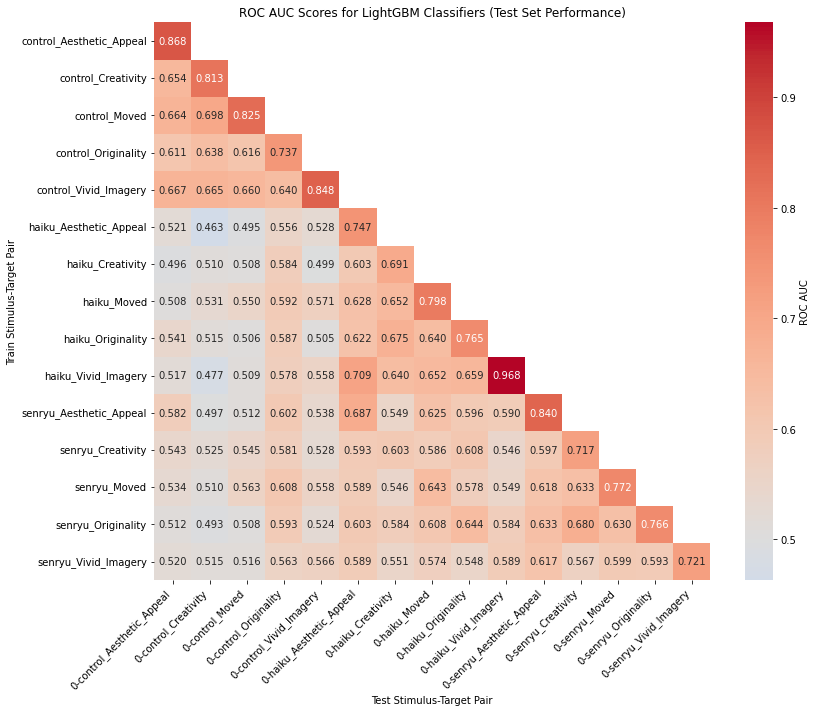

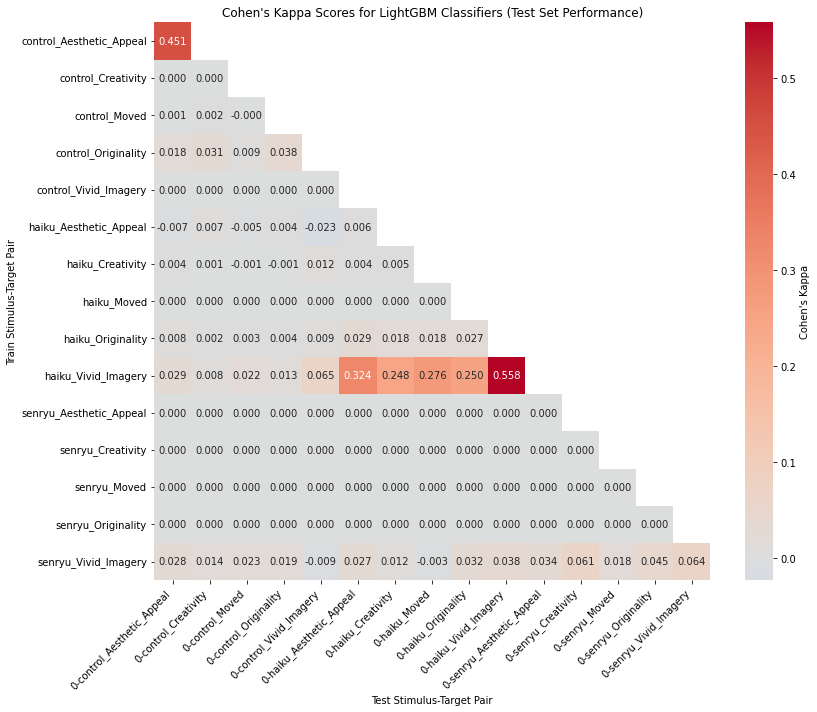

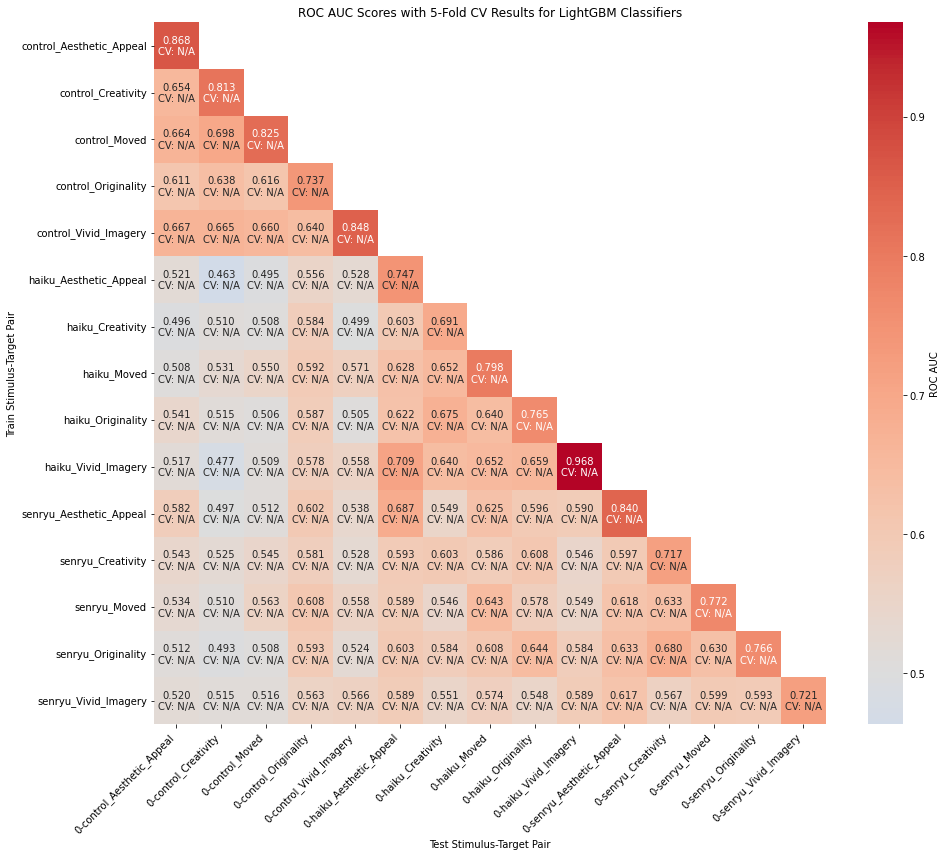

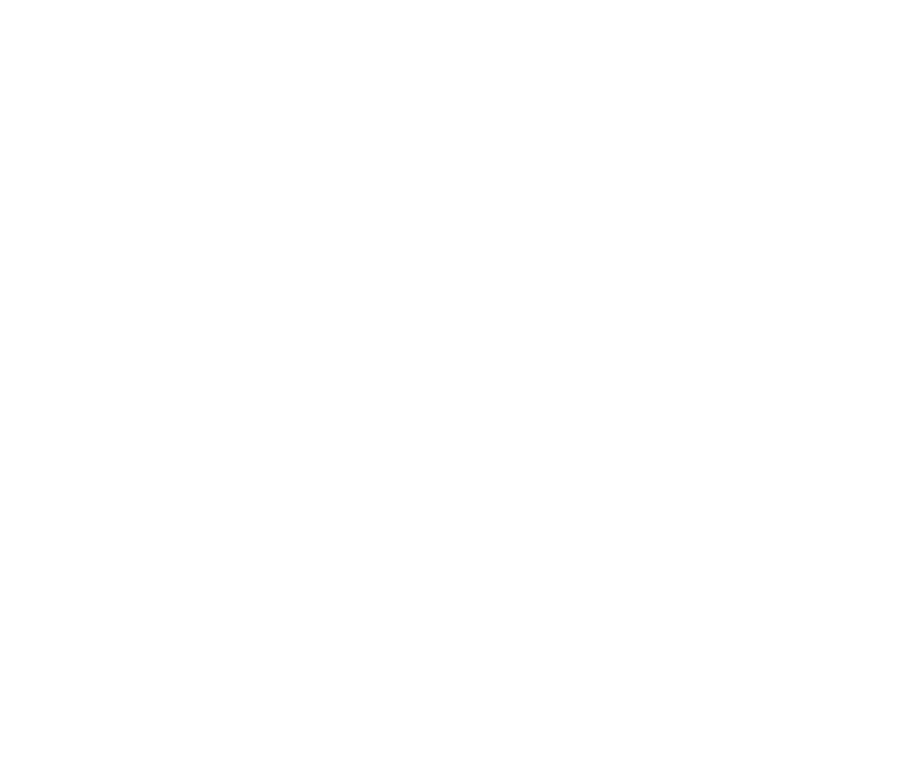

In [42]:
# Create triangular masks for upper part of the heatmap
mask_roc = np.zeros_like(roc_auc_df_lgb, dtype=bool)
mask_kappa = np.zeros_like(kappa_df_lgb, dtype=bool)
mask_combined = np.zeros_like(combined_roc_auc_df, dtype=bool)

# Fill upper triangle with True values to hide them
for i in range(mask_roc.shape[0]):
    for j in range(mask_roc.shape[1]):
        if j > i:  # Upper triangle
            mask_roc[i, j] = True
            mask_kappa[i, j] = True
            mask_combined[i, j] = True

            
# Plot ROC AUC heatmap (with triangle mask)
plt.figure(figsize=(12, 10))
ax = sns.heatmap(roc_auc_df_lgb, annot=True, cmap="coolwarm", fmt=".3f", 
              cbar_kws={'label': 'ROC AUC'}, center=0.5, mask=mask_roc)
plt.title("ROC AUC Scores for LightGBM Classifiers (Test Set Performance)")
plt.xlabel("Test Stimulus-Target Pair")
plt.ylabel("Train Stimulus-Target Pair")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot Kappa heatmap (with triangle mask)
plt.figure(figsize=(12, 10))
ax = sns.heatmap(kappa_df_lgb, annot=True, cmap="coolwarm", fmt=".3f", 
              cbar_kws={'label': 'Cohen\'s Kappa'}, center=0, mask=mask_kappa)
plt.title('Cohen\'s Kappa Scores for LightGBM Classifiers (Test Set Performance)')
plt.xlabel("Test Stimulus-Target Pair")
plt.ylabel("Train Stimulus-Target Pair")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot combined ROC AUC with CV scores heatmap (with triangle mask)
plt.figure(figsize=(14, 12))
ax = sns.heatmap(roc_auc_df_lgb, annot=combined_roc_auc_df, cmap="coolwarm", fmt="", 
              cbar_kws={'label': 'ROC AUC'}, center=0.5, mask=mask_combined)
plt.title("ROC AUC Scores with 5-Fold CV Results for LightGBM Classifiers")
plt.xlabel("Test Stimulus-Target Pair")
plt.ylabel("Train Stimulus-Target Pair")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Create a table-like visualization for detailed CV results
fig, ax = plt.figure(figsize=(16, 14)), plt.gca()
ax.axis('tight')
ax.axis('off')
table_data = []
headers = ["Train", "Test", "Test ROC AUC", "CV ROC AUC", "95% CI"]

for train_target, evaluations in lgb_results_matrix.items():
    for test_target, results in evaluations['performance'].items():
        test_auc = results['roc_auc']
        cv_auc = results['cv_roc_auc']
        
        if cv_auc is not None and results['cv_roc_auc_ci'] is not None:
            ci_lower, ci_upper = results['cv_roc_auc_ci']
            ci_str = f"[{ci_lower:.3f}, {ci_upper:.3f}]"
        else:
            ci_str = "N/A"
            
        table_data.append([
            train_target, 
            test_target, 
            f"{test_auc:.3f}", 
            f"{cv_auc:.3f}" if cv_auc is not None else "N/A",
            ci_str
        ])

In [24]:
# Sort by train target then test target for better readability
table_data.sort(key=lambda x: (x[0], x[1]))

# Create and save the table
table = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.savefig('lightgbm_cv_results_table.png', dpi=300, bbox_inches='tight')
plt.close()

## Create Combined Feature Importance and Coefficient Dataframe

In [26]:
def get_hierarchy_feature_names(features):
    cluster = []
    time_period = []
    frequency = []
    for feature in features:
        parts = feature.split('_')  # Split feature into parts
        cluster.append(parts[0])  # CL1, CL2, ...
        time_period.append(parts[1])  # (-4, 0), (0, 5), (5, 10)
        frequency.append(parts[2])  # alpha, beta, delta, lower gamma, theta
    return pd.DataFrame({
        'Cluster': cluster,
        'Time Period': time_period,
        'Frequency': frequency
    }, index=features)


In [27]:
# Extract LightGBM feature importances
lgb_coef = {}
all_feature_data = []

for stimulus_target in lightgbm_results.keys():
    
    # Get statsmodels coefficients
    sm_coefs = linear_results_sm[stimulus_target]['params']
    sm_pvals = linear_results_sm[stimulus_target]['p_values']
    
    # Get LightGBM feature importances
    lgb_importances = lightgbm_results[stimulus_target]['feature_importances']
    
    # Get feature names
    features = lightgbm_results[stimulus_target]['features']
    
    # Parse stimulus and target
    stimulus = stimulus_target.split('_')[0]
    target = '_'.join(stimulus_target.split('_')[1:])
    
    # Create a dataframe with hierarchical feature information
    hier_features = get_hierarchy_feature_names(features)
    
    # Create a dataframe for this stimulus-target combination
    for i, feature in enumerate(features):
        feature_data = {
            'stimulus': stimulus,
            'target': target,
            'feature': feature,
            'sm_coef': sm_coefs[i],
            'sm_pval': sm_pvals[i],
            'lgb_importance': lgb_importances[i],
            'cluster': hier_features.loc[feature, 'Cluster'],
            'time_period': hier_features.loc[feature, 'Time Period'],
            'frequency': hier_features.loc[feature, 'Frequency']
        }
        all_feature_data.append(feature_data)

# Convert to dataframe
all_models_df = pd.DataFrame(all_feature_data)

# Add significance indicators
all_models_df['sm_sig'] = all_models_df['sm_pval'] < 0.05

# Add absolute values for easier comparison
all_models_df['sm_coef_abs'] = np.abs(all_models_df['sm_coef'])

# Save the combined dataframe
all_models_df.to_csv('all_models_feature_comparison.csv', index=False)

print("Combined feature importance and coefficient dataframe created and saved.")

Combined feature importance and coefficient dataframe created and saved.
